# EDA 1 — Data validation

Five blocks, run before any estimation:

1. **Shape and integrity** per series
2. **Levels and returns** summary statistics
3. **Data quality flags** — stale runs, zero-return share, >5σ moves, non-positive prices, missingness
4. **Return construction** — roll detection, roll vs non-roll returns, roll exclusion downstream, sign check
5. **Coverage and attrition** per pair → `outputs/diagnostics/sample_attrition.csv`

Every series is read through `data_compile.py`. Cell status (`ok` / `src_na` / `no_row` / `uncovered`) comes from
the loader's status frames. Statistics on a single series use that series' **own rows** only, so a date another market
traded but this one did not is not counted as a gap here. That is a calendar difference, not missing data.

Two calendars are used, and the difference matters:

* **Own calendar** (sections 1–3): a return runs between consecutive rows of that series.
* **Joined calendar** (sections 4–5): a return runs between consecutive dates of the pair's inner join, so FX,
  commodity and controls cover the same interval. `Δs_{t+1}` is the FX return to the *next joined date*.
  This is a specification choice and has to be recorded in `design_decisions.md`.

Failed checks are printed and collected in a checks table at the end. They do not stop the run.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_compile import (START, END, RAW, BBG, FX_CSV, HG1_XLSX, OK, SRC_NA, NO_ROW, UNCOVERED,
                          curncy_df, curncy_status, comm_df, comm_status,
                          bcom_df, bcom_status, dxy_df, dxy_status)

OUT = Path("outputs") / "diagnostics"
OUT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# chart style: reference palette slots 1-2, recessive axes
BLUE, ORANGE, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": MUTED, "axes.linewidth": 0.6, "axes.labelcolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.labelsize": 9, "xtick.labelsize": 8,
    "ytick.labelsize": 8, "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "lines.linewidth": 1.4,
})

CHECKS = []
def check(section, name, passed, detail=""):
    # record a pass/fail; never raise, so a failed diagnostic stays in the output
    CHECKS.append({"section": section, "check": name, "result": "PASS" if passed else "FAIL", "detail": detail})
    print(f"[{'PASS' if passed else 'FAIL'}] {name}" + (f" - {detail}" if detail else ""))

In [2]:
FRAMES = {"curncy": (curncy_df, curncy_status), "comm": (comm_df, comm_status),
          "bcom": (bcom_df, bcom_status), "dxy": (dxy_df, dxy_status)}

OWN, STATUS, FRAME_OF = {}, {}, {}   # column -> own-row series / loader status / frame name
for frame, (df, st) in FRAMES.items():
    for c in df.columns:
        OWN[c] = df.loc[st[c].isin([OK, SRC_NA]), c]
        STATUS[c] = st[c]
        FRAME_OF[c] = frame

PRICES = [c for c in OWN if pd.api.types.is_numeric_dtype(OWN[c])]
TICKERS = [c for c in OWN if c not in PRICES]

# USDxxx quotes are local-per-USD: invert so + means the commodity currency appreciates
INVERT = {"AUDUSD_PX_LAST": False, "USDCAD_PX_LAST": True, "USDNOK_PX_LAST": True, "USDCLP_PX_LAST": True}
FX = list(INVERT)
FUT_TICKER = {"WTI_PX_LAST": "WTI_FUT_CUR_GEN_TICKER", "BRENT_PX_LAST": "BRENT_FUT_CUR_GEN_TICKER",
              "IRON_PX_LAST": "IRON_FUT_CUR_GEN_TICKER"}
COMMODITIES = ["WTI_PX_LAST", "BRENT_PX_LAST", "IRON_PX_LAST", "COPPER_PX_LAST", "HG1_PX_LAST"]
KIND = {**{c: "fx" for c in FX}, **{c: "commodity" for c in COMMODITIES},
        "BCOM_PX_LAST": "index", "DXY_PX_LAST": "index"}


def own_returns(c):
    # log return between consecutive own rows; NaN unless both prices present and positive.
    # FX is sign-adjusted (1/x for USDxxx). Roll days are NOT removed here - see roll_flags.
    s = OWN[c].astype(float)
    prev = s.shift()
    ratio = (s / prev).where(s.gt(0) & prev.gt(0))
    r = np.log(ratio)
    return -r if INVERT.get(c) else r


def roll_flags(c):
    # True on own rows where the generic's contract differs from the previous own row
    t = comm_df[FUT_TICKER[c]].reindex(OWN[c].index)
    return (t != t.shift()) & t.notna() & t.shift().notna()


def status_on(c, idx):
    # status of series c on an arbitrary date index: ok / src_na / no_row (inside own coverage) / uncovered
    s = OWN[c]
    v = s.reindex(idx)
    has_row = idx.isin(s.index)
    covered = (idx >= s.index.min()) & (idx <= s.index.max())
    return pd.Series(np.select([has_row & v.notna().to_numpy(), has_row, covered],
                               [OK, SRC_NA, NO_ROW], UNCOVERED), index=idx)


RET = {c: own_returns(c) for c in PRICES}
ROLL = {c: roll_flags(c) for c in FUT_TICKER}
print("price series:", PRICES)
print("ticker series:", TICKERS)

price series: ['AUDUSD_PX_LAST', 'USDCAD_PX_LAST', 'USDNOK_PX_LAST', 'USDCLP_PX_LAST', 'WTI_PX_LAST', 'BRENT_PX_LAST', 'IRON_PX_LAST', 'COPPER_PX_LAST', 'HG1_PX_LAST', 'BCOM_PX_LAST', 'DXY_PX_LAST']
ticker series: ['WTI_FUT_CUR_GEN_TICKER', 'BRENT_FUT_CUR_GEN_TICKER', 'IRON_FUT_CUR_GEN_TICKER']


## 1. Shape and integrity — per series

Rows, first and last date, dtype, missing count, duplicate dates, and whether the index is sorted and a real
datetime (not strings).

**Red flags:** a row count far from ~4,100 for 2010–2025, or any duplicate date.

`data_compile._finish` raises on duplicate dates and sorts the index, so on the *loaded* frames those two checks
pass by construction. Section 1b re-reads only the raw date columns to check the source files themselves.

In [3]:
rows = []
for c in OWN:
    s, st = OWN[c], STATUS[c]
    idx = s.index
    counts = st.value_counts()
    wk_window = len(pd.bdate_range(idx.min(), idx.max()))
    rows.append({
        "series": c, "frame": FRAME_OF[c], "dtype": str(s.dtype), "rows": len(s),
        "first_date": idx.min().date(), "last_date": idx.max().date(),
        "missing_src_na": int(counts[SRC_NA]), "no_row": int(counts[NO_ROW]), "uncovered": int(counts[UNCOVERED]),
        "weekdays_in_own_window": wk_window, "rows_vs_weekdays": len(s) / wk_window,
        "weekend_rows": int((idx.dayofweek >= 5).sum()),
        "dup_dates": int(idx.duplicated().sum()),
        "monotonic_increasing": bool(idx.is_monotonic_increasing),
        "index_dtype": str(idx.dtype), "has_time_component": bool((idx != idx.normalize()).any()),
    })
shape = pd.DataFrame(rows).set_index("series")
shape["red_flag"] = np.where(shape["dup_dates"] > 0, "DUPLICATE DATES",
                    np.where((shape["rows"] - 4100).abs() > 150, "rows far from ~4,100", ""))
shape.to_csv(OUT / "eda1_shape_integrity.csv")
shape

,frame,dtype,rows,first_date,last_date,missing_src_na,no_row,uncovered,weekdays_in_own_window,rows_vs_weekdays,weekend_rows,dup_dates,monotonic_increasing,index_dtype,has_time_component,red_flag
series,,,,,,,,,,,,,,,,
AUDUSD_PX_LAST,curncy,float64,4101,2010-01-01,2025-09-19,0,0,73,4101,1.0000,0,0,True,datetime64[us],False,
USDCAD_PX_LAST,curncy,float64,4101,2010-01-01,2025-09-19,0,0,73,4101,1.0000,0,0,True,datetime64[us],False,
USDNOK_PX_LAST,curncy,float64,4173,2010-01-01,2025-12-31,0,1,0,4174,0.9998,0,0,True,datetime64[us],False,
USDCLP_PX_LAST,curncy,float64,3898,2010-01-04,2025-12-31,0,275,1,4173,0.9341,0,0,True,datetime64[us],False,"rows far from ~4,100"
WTI_PX_LAST,comm,float64,3964,2010-01-04,2025-09-26,0,127,68,4105,0.9657,0,0,True,datetime64[us],False,
WTI_FUT_CUR_GEN_TICKER,comm,str,4030,2010-01-04,2025-12-31,0,129,0,4173,0.9657,0,0,True,datetime64[us],False,
BRENT_PX_LAST,comm,float64,4131,2010-01-04,2025-12-31,0,28,0,4173,0.9899,0,0,True,datetime64[us],False,
BRENT_FUT_CUR_GEN_TICKER,comm,str,4131,2010-01-04,2025-12-31,2,28,0,4173,0.9899,0,0,True,datetime64[us],False,
IRON_PX_LAST,comm,float64,3312,2013-04-08,2025-12-31,43,2,845,3323,0.9967,0,0,True,datetime64[us],False,"rows far from ~4,100"


In [4]:
for c, r in shape.iterrows():
    check("1", f"{c}: no duplicate dates", r.dup_dates == 0)
    check("1", f"{c}: index is datetime64, sorted, no time component",
          r.index_dtype.startswith("datetime64") and r.monotonic_increasing and not r.has_time_component)
for c, r in shape.loc[PRICES].iterrows():
    check("1", f"{c}: rows within 150 of ~4,100", abs(r.rows - 4100) <= 150,
          f"{r.rows} rows, {r.first_date} -> {r.last_date}")

[PASS] AUDUSD_PX_LAST: no duplicate dates
[PASS] AUDUSD_PX_LAST: index is datetime64, sorted, no time component
[PASS] USDCAD_PX_LAST: no duplicate dates
[PASS] USDCAD_PX_LAST: index is datetime64, sorted, no time component
[PASS] USDNOK_PX_LAST: no duplicate dates
[PASS] USDNOK_PX_LAST: index is datetime64, sorted, no time component
[PASS] USDCLP_PX_LAST: no duplicate dates
[PASS] USDCLP_PX_LAST: index is datetime64, sorted, no time component
[PASS] WTI_PX_LAST: no duplicate dates
[PASS] WTI_PX_LAST: index is datetime64, sorted, no time component
[PASS] WTI_FUT_CUR_GEN_TICKER: no duplicate dates
[PASS] WTI_FUT_CUR_GEN_TICKER: index is datetime64, sorted, no time component
[PASS] BRENT_PX_LAST: no duplicate dates
[PASS] BRENT_PX_LAST: index is datetime64, sorted, no time component
[PASS] BRENT_FUT_CUR_GEN_TICKER: no duplicate dates
[PASS] BRENT_FUT_CUR_GEN_TICKER: index is datetime64, sorted, no time component
[PASS] IRON_PX_LAST: no duplicate dates
[PASS] IRON_PX_LAST: index is dateti

### 1b. Raw date columns

The CSV readers in `data_compile` pass the date strings to `pd.to_datetime` **without a `format=`**. CLAUDE.md
forbids that because pandas then infers the format. This cell re-reads only the date columns as strings and
checks three things:

* every string matches `YYYY-MM-DD`;
* a strict `format="%Y-%m-%d"` parse gives exactly the loaded index;
* the raw file order and any raw duplicates.

If this passes, the inference happened to be right. The loader should still get an explicit format.

The `.xlsx` sources should come back as native Excel datetimes, so no format string applies. The check here is
that their date column's dtype is already `datetime64`.

In [5]:
CSV_DATES = {  # loaded column -> (raw file, raw date column)
    "AUDUSD_PX_LAST": (FX_CSV, "AUDUSD - Date"),
    "USDCAD_PX_LAST": (FX_CSV, "USDCAD - Date"),
    "WTI_PX_LAST": (RAW / "Crude_Oil_WTI_Spot_Daily.csv", "Date"),
    "BCOM_PX_LAST": (RAW / "Commodity_Index_BCOM_Price_Daily.csv", "Date"),
    "DXY_PX_LAST": (RAW / "USD_Index_DXY_Daily.csv", "Date"),
}
rows = []
for c, (path, col) in CSV_DATES.items():
    raw = pd.read_csv(path, usecols=[col], dtype=str)[col].dropna().str.strip()
    iso = raw.str.fullmatch(r"\d{4}-\d{2}-\d{2}")
    strict = pd.to_datetime(raw[iso], format="%Y-%m-%d")
    in_window = pd.DatetimeIndex(strict[(strict >= START) & (strict <= END)]).sort_values()
    rows.append({"series": c, "file": path.name, "raw_rows": len(raw), "non_iso_strings": int((~iso).sum()),
                 "raw_order": "ascending" if strict.is_monotonic_increasing else
                              "descending" if strict.is_monotonic_decreasing else "UNSORTED",
                 "raw_dup_dates": int(strict.duplicated().sum()),
                 "strict_parse_equals_loaded_index": in_window.equals(pd.DatetimeIndex(OWN[c].index))})
raw_dates = pd.DataFrame(rows).set_index("series")
display(raw_dates)
for c, r in raw_dates.iterrows():
    check("1b", f"{c}: raw dates all YYYY-MM-DD and strict parse == loaded index",
          r.non_iso_strings == 0 and r.strict_parse_equals_loaded_index,
          f"{r.non_iso_strings} non-ISO strings; order {r.raw_order}")

xl = {f"BBG.xlsx[{k}]": v["DATE"].dtype for k, v in pd.read_excel(BBG, sheet_name=None, usecols=["DATE"]).items()}
xl["Copper_Price_Daily.xlsx"] = pd.read_excel(HG1_XLSX, usecols=["Date"])["Date"].dtype
for k, dt in xl.items():
    check("1b", f"{k}: native Excel datetimes", str(dt).startswith("datetime64"), str(dt))

,file,raw_rows,non_iso_strings,raw_order,raw_dup_dates,strict_parse_equals_loaded_index
series,,,,,,
AUDUSD_PX_LAST,AT-04_Daily_Spot_Prices_G10_FX_Pairs_Daily_200...,6710,0,descending,0,True
USDCAD_PX_LAST,AT-04_Daily_Spot_Prices_G10_FX_Pairs_Daily_200...,6710,0,descending,0,True
WTI_PX_LAST,Crude_Oil_WTI_Spot_Daily.csv,7743,0,descending,0,True
BCOM_PX_LAST,Commodity_Index_BCOM_Price_Daily.csv,7715,0,descending,0,True
DXY_PX_LAST,USD_Index_DXY_Daily.csv,5185,0,ascending,0,True


[PASS] AUDUSD_PX_LAST: raw dates all YYYY-MM-DD and strict parse == loaded index - 0 non-ISO strings; order descending
[PASS] USDCAD_PX_LAST: raw dates all YYYY-MM-DD and strict parse == loaded index - 0 non-ISO strings; order descending
[PASS] WTI_PX_LAST: raw dates all YYYY-MM-DD and strict parse == loaded index - 0 non-ISO strings; order descending
[PASS] BCOM_PX_LAST: raw dates all YYYY-MM-DD and strict parse == loaded index - 0 non-ISO strings; order descending
[PASS] DXY_PX_LAST: raw dates all YYYY-MM-DD and strict parse == loaded index - 0 non-ISO strings; order ascending


[PASS] BBG.xlsx[wti]: native Excel datetimes - datetime64[us]
[PASS] BBG.xlsx[nok]: native Excel datetimes - datetime64[us]
[PASS] BBG.xlsx[clp]: native Excel datetimes - datetime64[us]
[PASS] BBG.xlsx[brent]: native Excel datetimes - datetime64[us]
[PASS] BBG.xlsx[iron]: native Excel datetimes - datetime64[us]
[PASS] BBG.xlsx[copper]: native Excel datetimes - datetime64[us]
[PASS] Copper_Price_Daily.xlsx: native Excel datetimes - datetime64[us]


## 2. Levels and returns

**Levels** are the raw quotes as pulled, not inverted, so each min and max can be checked on the terminal.
The min/max dates are what make that check possible.

**Returns** are own-calendar log returns in %. FX is sign-adjusted, so + means the commodity currency
appreciated. For the three front-month futures the statistics exclude roll days; `std_incl_roll_%` shows the
effect of leaving them in. Expected daily std: FX ~0.4–0.8%, commodities ~1.5–2.5%. Fat tails are normal and FX
skew should be near zero.

**Red flag:** a daily std above ~5% points to a broken return calculation, not to the market.

In [6]:
lv = []
for c in PRICES:
    s = OWN[c].dropna()
    lv.append({"series": c, "n": len(s), "min": s.min(), "min_date": s.idxmin().date(),
               "max": s.max(), "max_date": s.idxmax().date(), "mean": s.mean(), "median": s.median(), "std": s.std()})
levels = pd.DataFrame(lv).set_index("series")
levels.to_csv(OUT / "eda1_levels.csv")
levels

,n,min,min_date,max,max_date,mean,median,std
series,,,,,,,,
AUDUSD_PX_LAST,4101,0.5743,2020-03-19,1.1020,2011-07-27,0.7944,0.7501,0.1334
USDCAD_PX_LAST,4101,0.9433,2011-07-21,1.4579,2016-01-19,1.2279,1.2848,0.1434
USDNOK_PX_LAST,4173,5.2454,2011-04-28,11.7051,2020-03-20,8.1672,8.4051,1.7472
USDCLP_PX_LAST,3898,455.6600,2011-07-28,"1,048.5000",2022-07-14,696.6440,677.4850,155.1917
WTI_PX_LAST,3964,-37.6300,2020-04-20,123.7000,2022-03-08,71.7391,71.9250,20.9000
BRENT_PX_LAST,4131,19.3300,2020-04-21,127.9800,2022-03-08,77.7364,75.3900,23.5250
IRON_PX_LAST,3269,38.1500,2015-12-10,223.9400,2021-05-12,98.8804,98.4300,33.6894
COPPER_PX_LAST,4042,"4,331.0000",2016-01-15,"12,558.5000",2025-12-30,"7,478.8531","7,319.0000","1,597.0534"
HG1_PX_LAST,3967,194.3500,2016-01-15,579.5000,2025-07-23,338.4756,330.7500,74.1600


In [7]:
BAND = {"fx": (0.4, 0.8), "commodity": (1.5, 2.5)}
rs = []
for c in PRICES:
    r_all = RET[c].dropna()
    r = RET[c][~ROLL[c]].dropna() if c in ROLL else r_all
    lo, hi = BAND.get(KIND[c], (np.nan, np.nan))
    sd = 100 * r.std()
    rs.append({"series": c + (" (ex-roll)" if c in ROLL else ""), "kind": KIND[c], "n": len(r),
               "undefined_(price<=0)": int((OWN[c].le(0) | OWN[c].shift().le(0)).sum()),
               "mean_%": 100 * r.mean(), "std_%": sd, "ann_vol_%": sd * np.sqrt(252),
               "std_incl_roll_%": 100 * r_all.std() if c in ROLL else np.nan,
               "skew": r.skew(), "excess_kurt": r.kurt(),
               "min_%": 100 * r.min(), "min_date": r.idxmin().date(),
               "max_%": 100 * r.max(), "max_date": r.idxmax().date(),
               "band_%": f"{lo}-{hi}" if lo == lo else "", "in_band": (lo <= sd <= hi) if lo == lo else None})
retstats = pd.DataFrame(rs).set_index("series")
retstats.to_csv(OUT / "eda1_return_stats.csv")
display(retstats)

for c, r in retstats.iterrows():
    check("2", f"{c}: daily std below 5%", r["std_%"] < 5, f"{r['std_%']:.2f}%")
    if r.in_band is not None:
        check("2", f"{c}: daily std in expected {r.kind} band {r['band_%']}%", bool(r.in_band), f"{r['std_%']:.2f}%")
for c in FX:
    sk = retstats.loc[c, "skew"]
    check("2", f"{c}: FX skew near zero (|skew| < 0.5)", abs(sk) < 0.5, f"skew {sk:.2f}")

,kind,n,undefined_(price<=0),mean_%,std_%,ann_vol_%,std_incl_roll_%,skew,excess_kurt,min_%,min_date,max_%,max_date,band_%,in_band
series,,,,,,,,,,,,,,,
AUDUSD_PX_LAST,fx,4100,0,-0.0074,0.6668,10.5850,NaN,-0.2055,2.7058,-4.6738,2025-04-04,3.5750,2010-05-27,0.4-0.8,True
USDCAD_PX_LAST,fx,4100,0,-0.0066,0.4777,7.5839,NaN,-0.0886,1.7831,-2.4978,2010-05-20,2.1518,2010-05-27,0.4-0.8,True
USDNOK_PX_LAST,fx,4172,0,-0.0134,0.7395,11.7387,NaN,-0.5025,4.2846,-7.2554,2020-03-18,4.0663,2020-03-24,0.4-0.8,True
USDCLP_PX_LAST,fx,3897,0,-0.0148,0.7650,12.1437,NaN,-0.0318,4.5847,-4.6792,2011-11-30,7.3694,2022-07-15,0.4-0.8,True
WTI_PX_LAST (ex-roll),commodity,3772,2,0.0006,2.5092,39.8330,2.5528,-0.4783,20.9485,-28.2206,2020-03-09,22.3940,2020-04-30,1.5-2.5,False
BRENT_PX_LAST (ex-roll),commodity,3937,0,0.0076,2.1786,34.5845,2.2121,-1.0096,18.8323,-27.9761,2020-04-21,19.0774,2020-04-02,1.5-2.5,True
IRON_PX_LAST (ex-roll),commodity,3103,0,0.0530,1.2814,20.3412,1.8004,0.4104,10.4138,-7.7960,2021-09-06,14.9249,2016-03-07,1.5-2.5,False
COPPER_PX_LAST,commodity,4041,0,0.0125,1.3283,21.0864,NaN,-0.1887,2.5292,-8.0740,2020-03-18,6.8737,2022-11-04,1.5-2.5,False
HG1_PX_LAST,commodity,3956,0,0.0079,1.4999,23.8099,NaN,-1.1901,21.7856,-24.9054,2025-07-31,12.4437,2025-07-08,1.5-2.5,False


[PASS] AUDUSD_PX_LAST: daily std below 5% - 0.67%
[PASS] AUDUSD_PX_LAST: daily std in expected fx band 0.4-0.8% - 0.67%
[PASS] USDCAD_PX_LAST: daily std below 5% - 0.48%
[PASS] USDCAD_PX_LAST: daily std in expected fx band 0.4-0.8% - 0.48%
[PASS] USDNOK_PX_LAST: daily std below 5% - 0.74%
[PASS] USDNOK_PX_LAST: daily std in expected fx band 0.4-0.8% - 0.74%
[PASS] USDCLP_PX_LAST: daily std below 5% - 0.76%
[PASS] USDCLP_PX_LAST: daily std in expected fx band 0.4-0.8% - 0.76%
[PASS] WTI_PX_LAST (ex-roll): daily std below 5% - 2.51%
[FAIL] WTI_PX_LAST (ex-roll): daily std in expected commodity band 1.5-2.5% - 2.51%
[PASS] BRENT_PX_LAST (ex-roll): daily std below 5% - 2.18%
[PASS] BRENT_PX_LAST (ex-roll): daily std in expected commodity band 1.5-2.5% - 2.18%
[PASS] IRON_PX_LAST (ex-roll): daily std below 5% - 1.28%
[FAIL] IRON_PX_LAST (ex-roll): daily std in expected commodity band 1.5-2.5% - 1.28%
[PASS] COPPER_PX_LAST: daily std below 5% - 1.33%
[FAIL] COPPER_PX_LAST: daily std in expec

## 3. Data quality flags

### 3a. Longest run of identical consecutive prices

Taken over own rows. A run of more than 3–4 sessions in a liquid market usually means a stale feed.

In [8]:
def runs(s):
    # all runs of identical consecutive non-NA values: length, first/last date, value
    s = s.dropna()
    g = (s != s.shift()).cumsum()
    out = s.groupby(g).agg(["size", "first"]).rename(columns={"size": "length", "first": "value"})
    out["from"] = s.index.to_series().groupby(g.values).min().values
    out["to"] = s.index.to_series().groupby(g.values).max().values
    return out.sort_values("length", ascending=False)

lr = []
for c in PRICES:
    r = runs(OWN[c])
    top = r.iloc[0]
    lr.append({"series": c, "longest_run": int(top.length), "value": top.value, "from": top["from"].date(),
               "to": top["to"].date(), "runs_ge_3": int((r.length >= 3).sum()), "runs_ge_5": int((r.length >= 5).sum())})
stale = pd.DataFrame(lr).set_index("series")
display(stale)
for c, r in stale.iterrows():
    check("3a", f"{c}: longest identical run < 5 sessions", r.longest_run < 5,
          f"{r.longest_run} x {r.value} ({r['from']} -> {r['to']})")

,longest_run,value,from,to,runs_ge_3,runs_ge_5
series,,,,,,
AUDUSD_PX_LAST,2,0.9030,2013-08-23,2013-08-26,0,0
USDCAD_PX_LAST,3,1.3282,2019-11-27,2019-11-29,1,0
USDNOK_PX_LAST,2,7.4520,2014-12-31,2015-01-01,0,0
USDCLP_PX_LAST,3,592.2500,2014-09-10,2014-09-12,3,0
WTI_PX_LAST,2,87.8100,2010-11-10,2010-11-11,0,0
BRENT_PX_LAST,2,63.4500,2015-04-17,2015-04-20,0,0
IRON_PX_LAST,4,134.2500,2013-09-24,2013-09-27,9,0
COPPER_PX_LAST,3,"8,050.0000",2012-04-17,2012-04-19,1,0
HG1_PX_LAST,3,371.8000,2012-10-08,2012-10-10,1,0


[PASS] AUDUSD_PX_LAST: longest identical run < 5 sessions - 2 x 0.903 (2013-08-23 -> 2013-08-26)
[PASS] USDCAD_PX_LAST: longest identical run < 5 sessions - 3 x 1.3282 (2019-11-27 -> 2019-11-29)
[PASS] USDNOK_PX_LAST: longest identical run < 5 sessions - 2 x 7.452 (2014-12-31 -> 2015-01-01)
[PASS] USDCLP_PX_LAST: longest identical run < 5 sessions - 3 x 592.25 (2014-09-10 -> 2014-09-12)
[PASS] WTI_PX_LAST: longest identical run < 5 sessions - 2 x 87.81 (2010-11-10 -> 2010-11-11)
[PASS] BRENT_PX_LAST: longest identical run < 5 sessions - 2 x 63.45 (2015-04-17 -> 2015-04-20)
[PASS] IRON_PX_LAST: longest identical run < 5 sessions - 4 x 134.25 (2013-09-24 -> 2013-09-27)
[PASS] COPPER_PX_LAST: longest identical run < 5 sessions - 3 x 8050.0 (2012-04-17 -> 2012-04-19)
[PASS] HG1_PX_LAST: longest identical run < 5 sessions - 3 x 371.8 (2012-10-08 -> 2012-10-10)
[PASS] BCOM_PX_LAST: longest identical run < 5 sessions - 1 x 142.3014 (2010-01-04 -> 2010-01-04)
[PASS] DXY_PX_LAST: longest identi

### 3b. Rolling 60-day zero-return share

This is the share of the last 60 own-calendar returns that are exactly zero. A high share means the price is not
updating. The `VOLUME` pull for iron ore came back empty, so this is now the start-date diagnostic for the AUD pair.

The cell reports when the iron-ore share first drops below and then *stays* below 5% and 10%, as information.
The start-date rule has to be fixed in `design_decisions.md` **before** estimation, from this chart and not from
regression output. Caveat for iron ore: the contract settles on a monthly average (section 4b-ii), so late-month
prices barely move and round to zero more often. Some of the zero-return share is settlement mechanics, not
illiquidity.

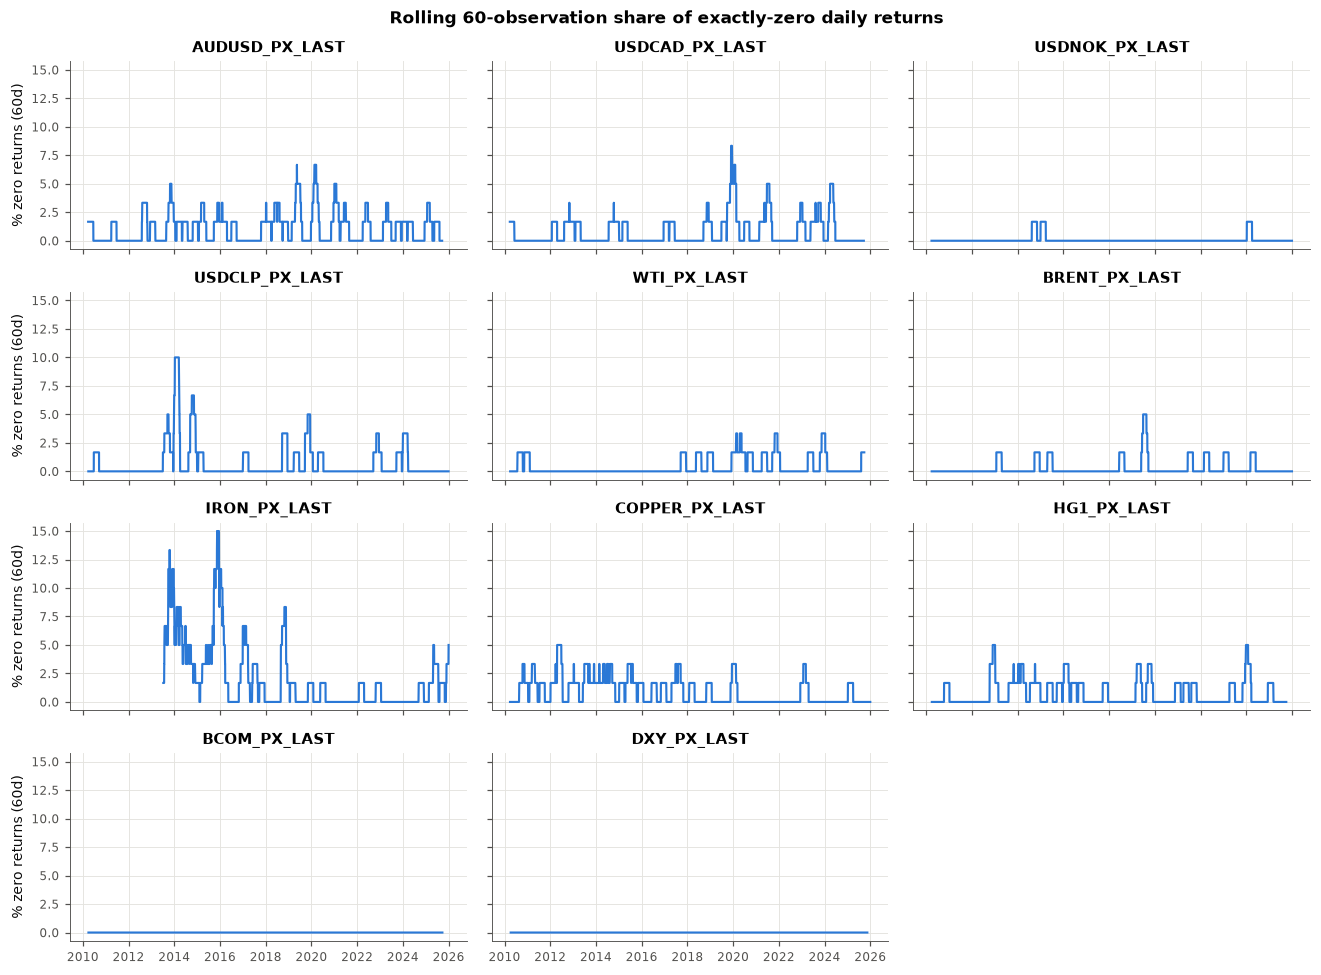

Zero-return share by year, %


,AUDUSD_PX_LAST,USDCAD_PX_LAST,USDNOK_PX_LAST,USDCLP_PX_LAST,WTI_PX_LAST,BRENT_PX_LAST,IRON_PX_LAST,COPPER_PX_LAST,HG1_PX_LAST,BCOM_PX_LAST,DXY_PX_LAST
year,,,,,,,,,,,
2010,0.4000,0.4000,0.0000,0.4000,0.8000,0.0000,NaN,0.8000,0.4000,0.0000,0.0000
2011,0.4000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,1.2000,0.0000,0.0000,0.0000
2012,1.1000,1.1000,0.0000,0.0000,0.0000,0.0000,NaN,2.0000,1.2000,0.0000,0.0000
2013,1.1000,0.4000,0.0000,2.9000,0.0000,0.4000,6.4000,2.0000,0.8000,0.0000,0.0000
2014,1.1000,0.8000,0.4000,2.4000,0.0000,0.4000,4.3000,1.6000,1.6000,0.0000,0.0000
2015,1.5000,0.4000,0.4000,0.4000,0.0000,0.4000,7.5000,2.0000,1.2000,0.0000,0.0000
2016,0.8000,0.4000,0.0000,0.0000,0.0000,0.0000,2.0000,0.8000,1.2000,0.0000,0.0000
2017,0.4000,0.4000,0.0000,0.4000,0.4000,0.0000,1.6000,1.2000,0.4000,0.0000,0.0000
2018,1.9000,0.8000,0.0000,0.8000,0.8000,0.4000,1.9000,0.8000,0.0000,0.0000,0.0000


In [9]:
ZW = 60
zshare = {c: RET[c].dropna().eq(0).rolling(ZW).mean() for c in PRICES}

fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharex=True, sharey=True)
for ax, c in zip(axes.flat, PRICES):
    ax.plot(zshare[c].index, 100 * zshare[c], color=BLUE)
    ax.set_title(c)
for ax in axes.flat[len(PRICES):]:
    ax.set_visible(False)
for ax in axes[:, 0]:
    ax.set_ylabel("% zero returns (60d)")
fig.suptitle("Rolling 60-observation share of exactly-zero daily returns", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

zy = pd.DataFrame({c: RET[c].dropna().eq(0).groupby(RET[c].dropna().index.year).mean() * 100 for c in PRICES})
zy.index.name = "year"
print("Zero-return share by year, %")
display(zy.round(1))

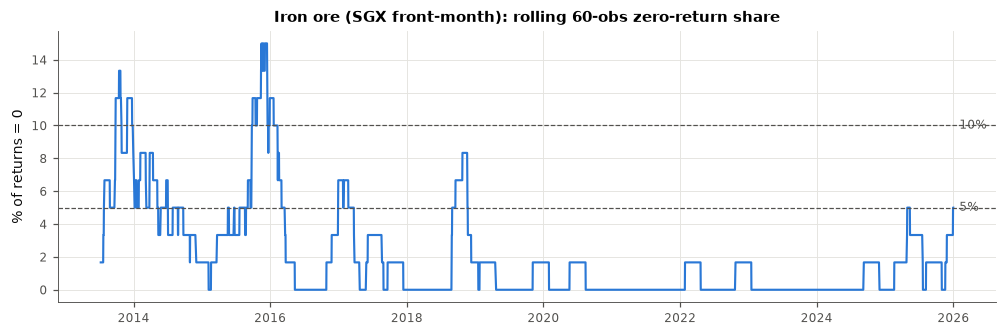

>= 5%: 547 of 3167 windows; first 2013-07-26, last 2025-12-31; stays below from never (at/above at sample end)
>= 10%: 134 of 3167 windows; first 2013-09-26, last 2016-02-09; stays below from 2016-02-10
first iron ore price: 2013-04-08


In [10]:
iz = zshare["IRON_PX_LAST"].dropna()
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(iz.index, 100 * iz, color=BLUE)
for thr in (5, 10):
    ax.axhline(thr, color=MUTED, lw=0.8, ls="--")
    ax.annotate(f"{thr}%", (iz.index[-1], thr), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=MUTED)
ax.set_title("Iron ore (SGX front-month): rolling 60-obs zero-return share")
ax.set_ylabel("% of returns = 0")
plt.show()

for thr in (0.05, 0.10):
    above = iz[iz >= thr]
    after = iz.index[iz.index > above.index.max()] if len(above) else iz.index
    print(f">= {thr:.0%}: {len(above)} of {len(iz)} windows; first {above.index.min().date() if len(above) else '-'}, "
          f"last {above.index.max().date() if len(above) else '-'}; "
          f"stays below from {after[0].date() if len(after) else 'never (at/above at sample end)'}")
print(f"first iron ore price: {OWN['IRON_PX_LAST'].first_valid_index().date()}")

### 3c. Every |return| > 5σ

σ is each series' full-sample std of own-calendar returns, excluding roll days for the futures. Roll-day moves are
listed too, marked `roll_day`, because they are excluded downstream anyway. Each move is matched to a known
event within the date window given in `EVENTS`. `days_spanned` gives the calendar days since the previous row. A
large value means the "daily" return actually runs across a data gap.

Anything marked **UNEXPLAINED** needs a terminal check before it can be kept. It could be a data error, or a real
move that isn't in the list.

In [11]:
EVENTS = [  # (from, to, description) - inclusive windows
    ("2010-05-17", "2010-05-27", "May-2010 euro-area sovereign stress (German naked-short ban 18/19-May; rebound 27-May)"),
    ("2011-01-03", "2011-01-04", "BCCh announces USD 12bn reserve-purchase programme (3-Jan-2011)"),
    ("2011-05-05", "2011-05-05", "Commodity sell-off: silver and oil crash (5-May-2011)"),
    ("2011-09-22", "2011-09-22", "Risk-off after FOMC 'Operation Twist' (21-Sep-2011) and weak China PMI"),
    ("2011-10-31", "2011-11-01", "Greek referendum call (31-Oct-2011)"),
    ("2013-06-20", "2013-06-20", "Taper tantrum: Bernanke press conference (19-Jun-2013)"),
    ("2015-01-15", "2015-01-15", "SNB removes EUR/CHF floor"),
    ("2015-08-24", "2015-08-24", "China 'Black Monday'"),
    ("2016-03-07", "2016-03-07", "China steel/iron-ore futures surge after NPC growth target (7-Mar-2016)"),
    ("2016-03-17", "2016-03-17", "Dovish FOMC (16-Mar-2016)"),
    ("2016-06-24", "2016-06-24", "Brexit referendum result"),
    ("2016-11-09", "2016-11-09", "US presidential election result"),
    ("2016-12-15", "2016-12-15", "FOMC hike and hawkish dots (14-Dec-2016)"),
    ("2019-09-16", "2019-09-16", "Abqaiq/Khurais attack on Saudi facilities (14-Sep-2019)"),
    ("2020-03-06", "2020-03-31", "COVID-19 crash / USD funding squeeze; OPEC+ collapse 6-Mar, price war 9-Mar"),
    ("2020-04-01", "2020-04-03", "Trump signals Saudi-Russia output cut (2-Apr-2020)"),
    ("2020-04-20", "2020-05-06", "Oil storage crisis: CLK20 settles -$37.63 (20-Apr); extreme front-month volatility"),
    ("2021-11-26", "2021-11-26", "Omicron variant announced"),
    ("2022-03-07", "2022-03-09", "Russia-Ukraine commodity spike and reversal (Brent -13% on 9-Mar)"),
    ("2022-07-05", "2022-07-05", "Recession-fear commodity sell-off (5-Jul-2022)"),
    ("2022-07-14", "2022-07-15", "BCCh announces USD 25bn FX intervention (evening 14-Jul-2022)"),
    ("2022-11-04", "2022-11-04", "China reopening speculation (4-Nov-2022)"),
    ("2025-04-03", "2025-04-09", "US 'Liberation Day' tariffs (2-Apr-2025) and China retaliation (4-Apr)"),
    ("2025-07-08", "2025-07-08", "US announces 50% copper tariff (8-Jul-2025) - COMEX only"),
    ("2025-07-31", "2025-07-31", "US exempts refined copper from tariff - COMEX -22%, absent from LME"),
]

def event_for(d):
    hits = [e for a, b, e in EVENTS if pd.Timestamp(a) <= d <= pd.Timestamp(b)]
    return "; ".join(hits)

SIG = 5.0
fl = []
for c in PRICES:
    roll = ROLL.get(c, pd.Series(False, index=RET[c].index))
    r = RET[c]
    sd = r[~roll].std()
    prev = OWN[c].shift()
    span = OWN[c].index.to_series().diff().dt.days
    for d in r.index[r.abs() > SIG * sd]:
        ev = "roll day (contract switch) - excluded downstream" if roll[d] else event_for(d)
        fl.append({"series": c, "date": d.date(), "days_spanned": int(span[d]), "price": OWN[c][d], "prev_price": prev[d],
                   "return_%": 100 * r[d], "z": r[d] / sd, "roll_day": bool(roll[d]),
                   "event": ev or "UNEXPLAINED - verify on terminal"})
big = pd.DataFrame(fl).sort_values(["series", "date"], ignore_index=True)
big.to_csv(OUT / "eda1_gt5sigma.csv", index=False)
print(f"{len(big)} returns beyond {SIG:.0f} sigma "
      f"({big.roll_day.sum()} on roll days, {big.event.str.startswith('UNEXPLAINED').sum()} unexplained)")
big

104 returns beyond 5 sigma (37 on roll days, 7 unexplained)


,series,date,days_spanned,price,prev_price,return_%,z,roll_day,event
0,AUDUSD_PX_LAST,2010-05-20,1,0.8172,0.8472,-3.6053,-5.4069,False,May-2010 euro-area sovereign stress (German na...
1,AUDUSD_PX_LAST,2010-05-27,1,0.8514,0.8215,3.5750,5.3615,False,May-2010 euro-area sovereign stress (German na...
2,AUDUSD_PX_LAST,2020-03-12,1,0.6236,0.6484,-3.8999,-5.8487,False,COVID-19 crash / USD funding squeeze; OPEC+ co...
3,AUDUSD_PX_LAST,2020-03-18,1,0.5773,0.6000,-3.8568,-5.7840,False,COVID-19 crash / USD funding squeeze; OPEC+ co...
4,AUDUSD_PX_LAST,2025-04-04,1,0.6040,0.6329,-4.6738,-7.0094,False,US 'Liberation Day' tariffs (2-Apr-2025) and C...
5,BCOM_PX_LAST,2011-05-05,1,161.0196,168.9085,-4.7831,-5.2543,False,Commodity sell-off: silver and oil crash (5-Ma...
6,BCOM_PX_LAST,2022-03-09,1,125.8394,132.6339,-5.2586,-5.7767,False,Russia-Ukraine commodity spike and reversal (B...
7,BCOM_PX_LAST,2022-07-05,4,111.8706,117.1284,-4.5928,-5.0453,False,Recession-fear commodity sell-off (5-Jul-2022)
8,BRENT_PX_LAST,2019-09-16,3,69.0200,60.2200,13.6392,6.2605,False,Abqaiq/Khurais attack on Saudi facilities (14-...
9,BRENT_PX_LAST,2020-03-09,3,34.3600,45.2700,-27.5751,-12.6572,False,COVID-19 crash / USD funding squeeze; OPEC+ co...


In [12]:
unexp = big[big.event.str.startswith("UNEXPLAINED")]
check("3c", "every non-roll >5sigma move matched to a known event", unexp.empty,
      "; ".join(f"{r.series} {r.date}" for r in unexp.itertuples()))

[FAIL] every non-roll >5sigma move matched to a known event - COPPER_PX_LAST 2011-10-20; IRON_PX_LAST 2016-11-11; IRON_PX_LAST 2017-05-04; IRON_PX_LAST 2021-05-10; IRON_PX_LAST 2021-09-06; IRON_PX_LAST 2021-10-11; USDCLP_PX_LAST 2011-11-30


### 3d. Non-positive prices

A log return is undefined whenever either endpoint is ≤ 0. WTI's −$37.63 on 2020-04-20 makes both the 04-20 and
the 04-21 returns undefined. The notebook takes no position on how to treat this. It shows up as its own
attrition stage in section 5 until `design_decisions.md` records a choice (simple returns / exclude / winsorize).

In [13]:
nonpos = pd.DataFrame([{"series": c, "date": d.date(), "price": p, "prev_price": OWN[c].shift()[d],
                        "next_price": OWN[c].shift(-1)[d]}
                       for c in PRICES for d, p in OWN[c][OWN[c] <= 0].items()])
display(nonpos if len(nonpos) else "no non-positive prices")
check("3d", "non-positive prices limited to WTI 2020-04-20",
      len(nonpos) == 1 and nonpos.iloc[0].series == "WTI_PX_LAST" and str(nonpos.iloc[0].date) == "2020-04-20",
      f"{len(nonpos)} found")

,series,date,price,prev_price,next_price
0,WTI_PX_LAST,2020-04-20,-37.6300,18.2700,10.0100


[PASS] non-positive prices limited to WTI 2020-04-20 - 1 found


### 3e. Missingness heatmap, series × year

The reference calendar is Monday–Friday. Each cell counts weekdays **inside the series' own coverage** with no
usable value (`src_na` + `no_row` + weekdays absent from the source). Most of those are that market's holidays,
at roughly 5–15 a year. Grey cells are years entirely outside coverage. `*` marks a year only partly covered,
where the uncovered weekdays are not counted. The table below the chart splits the counts by status.

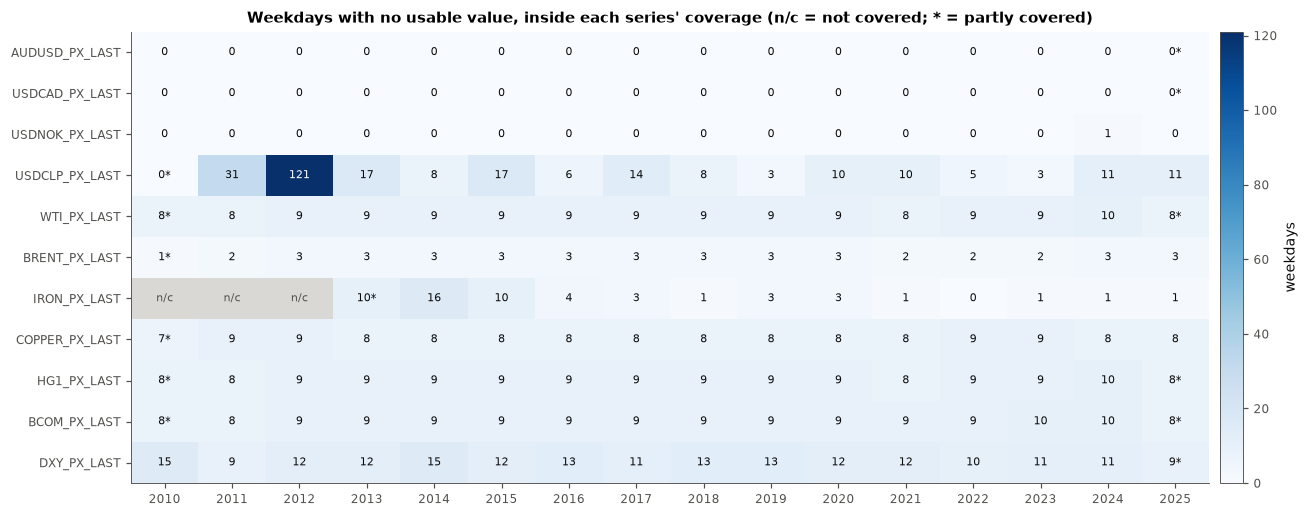

,ok,src_na,no_row,uncovered,gaps_per_covered_year
AUDUSD_PX_LAST,4101,0,0,73,0.0000
USDCAD_PX_LAST,4101,0,0,73,0.0000
USDNOK_PX_LAST,4173,0,1,0,0.0625
USDCLP_PX_LAST,3898,0,275,1,17.1999
WTI_PX_LAST,3964,0,141,69,8.9649
BRENT_PX_LAST,4131,0,42,1,2.6269
IRON_PX_LAST,3269,43,11,851,4.2413
COPPER_PX_LAST,4042,0,131,1,8.1934
HG1_PX_LAST,3967,10,131,66,8.9584
BCOM_PX_LAST,3959,0,143,72,9.0987


In [14]:
WEEKDAYS = pd.bdate_range(START, END)

WS = pd.DataFrame({c: status_on(c, WEEKDAYS) for c in PRICES})
yr = WS.index.year
gaps = WS.isin([SRC_NA, NO_ROW]).groupby(yr).sum().T
unc = WS.eq(UNCOVERED).groupby(yr).sum().T
n_wd = pd.Series(1, index=WEEKDAYS).groupby(yr).sum()

fig, ax = plt.subplots(figsize=(12, 4.8))
m = np.ma.masked_where(unc.values == n_wd.values, gaps.values)
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#d9d8d4")
im = ax.imshow(m, aspect="auto", cmap=cmap, vmin=0, vmax=max(20, gaps.values.max()))
for i in range(gaps.shape[0]):
    for j in range(gaps.shape[1]):
        if unc.values[i, j] == n_wd.values[j]:
            txt, col = "n/c", MUTED
        else:
            v = gaps.values[i, j]
            txt = f"{v}{'*' if unc.values[i, j] else ''}"
            col = "white" if v > 0.6 * im.norm.vmax else INK
        ax.text(j, i, txt, ha="center", va="center", fontsize=7, color=col)
ax.set_xticks(range(gaps.shape[1]), gaps.columns)
ax.set_yticks(range(gaps.shape[0]), gaps.index)
ax.grid(False)
ax.set_title("Weekdays with no usable value, inside each series' coverage (n/c = not covered; * = partly covered)")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01, label="weekdays")
fig.tight_layout()
plt.show()

by_status = WS.apply(lambda s: s.value_counts()).T.reindex(columns=[OK, SRC_NA, NO_ROW, UNCOVERED]).fillna(0).astype(int)
by_status["gaps_per_covered_year"] = (by_status[SRC_NA] + by_status[NO_ROW]) / ((len(WEEKDAYS) - by_status[UNCOVERED]) / 261)
by_status

## 4. Return construction validation

### 4a. Roll counts

A roll is a change in `FUT_CUR_GEN_TICKER` between consecutive own rows, and there should be about 12 a year.
Iron ore starts in 2013-04, so it should land nearer 150 than 190. The cell also parses each contract code and
checks that every roll moves **forward exactly one month**. A step back, or a skipped month, would mean the
ticker column is misaligned with the price column.

`LMCADS03` is constant-maturity and never rolls. HG1 has no ticker column, so its rolls cannot be detected. That
is accepted, not fixed: see CLAUDE.md. The required robustness check is `BCOM⊥` rebuilt on LME copper.

In [15]:
MONTH = {m: i + 1 for i, m in enumerate("FGHJKMNQUVXZ")}

def contract_month(code, prefix):
    # 'CLG10' -> 2010-02, 'CLG6' -> 2026-02 (Bloomberg uses one year digit for the current decade)
    body = code[len(prefix):]
    m, y = MONTH[body[0]], body[1:]
    year = 2000 + int(y) if len(y) == 2 else 2020 + int(y)
    return year * 12 + (m - 1)

PREFIX = {"WTI_PX_LAST": "CL", "BRENT_PX_LAST": "CO", "IRON_PX_LAST": "SCO"}
rc, per_year = [], {}
for c, tcol in FUT_TICKER.items():
    t = comm_df[tcol].reindex(OWN[c].index).dropna()
    ch = t[t != t.shift()].iloc[1:]
    step = pd.Series([contract_month(x, PREFIX[c]) for x in t], index=t.index).diff()[ch.index]
    per_year[c] = ch.groupby(ch.index.year).size()
    rc.append({"series": c, "first": t.index.min().date(), "last": t.index.max().date(),
               "rolls": len(ch), "years": round(len(t) / 252, 1), "rolls_per_year": len(ch) / (len(t) / 252),
               "steps_of_1_month": int((step == 1).sum()), "other_steps": step[step != 1].astype(int).to_dict()})
rolls = pd.DataFrame(rc).set_index("series")
display(rolls)
display(pd.DataFrame(per_year).fillna(0).astype(int).rename_axis("year").T)

for c, r in rolls.iterrows():
    check("4a", f"{c}: ~12 rolls/year", 10.5 <= r.rolls_per_year <= 13.5, f"{r.rolls} rolls, {r.rolls_per_year:.1f}/yr")
    check("4a", f"{c}: every roll steps forward one contract month", not r.other_steps, str(r.other_steps))

,first,last,rolls,years,rolls_per_year,steps_of_1_month,other_steps
series,,,,,,,
WTI_PX_LAST,2010-01-04,2025-09-26,189,15.7000,12.0151,189,{}
BRENT_PX_LAST,2010-01-04,2025-12-31,193,16.4000,11.7791,193,{}
IRON_PX_LAST,2013-04-08,2025-12-31,152,13.1000,11.5652,152,{}


year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
WTI_PX_LAST,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,9
BRENT_PX_LAST,12,12,12,12,12,12,13,12,12,12,12,12,12,12,12,12
IRON_PX_LAST,0,0,0,8,12,12,12,12,13,11,12,12,12,12,12,12


[PASS] WTI_PX_LAST: ~12 rolls/year - 189 rolls, 12.0/yr
[PASS] WTI_PX_LAST: every roll steps forward one contract month - {}
[PASS] BRENT_PX_LAST: ~12 rolls/year - 193 rolls, 11.8/yr
[PASS] BRENT_PX_LAST: every roll steps forward one contract month - {}
[PASS] IRON_PX_LAST: ~12 rolls/year - 152 rolls, 11.6/yr
[PASS] IRON_PX_LAST: every roll steps forward one contract month - {}


### 4b. Roll-day vs non-roll-day returns (before exclusion)

On a roll day the generic's return mixes the market move with the calendar spread between the two contracts, so
the roll-day distribution should be fatter. For iron ore, which rolls at expiry in a market that is often
backwardated, the gap is large. For crude the front–second spread is usually well under 1%, so expect a
visible shift but not a dramatic one.

The strongest evidence that roll detection works is the **event-study table**. Mean |r| should peak at offset 0,
the flagged day. A peak at ±1 would mean the ticker column is one day off the price column. That is a real risk
for WTI, where the price comes from the CSV and the ticker from `BBG.xlsx`.

The permutation p-value asks how often a random draw of non-roll days, of the same size, has a mean |r| at least
as large as the roll days'.

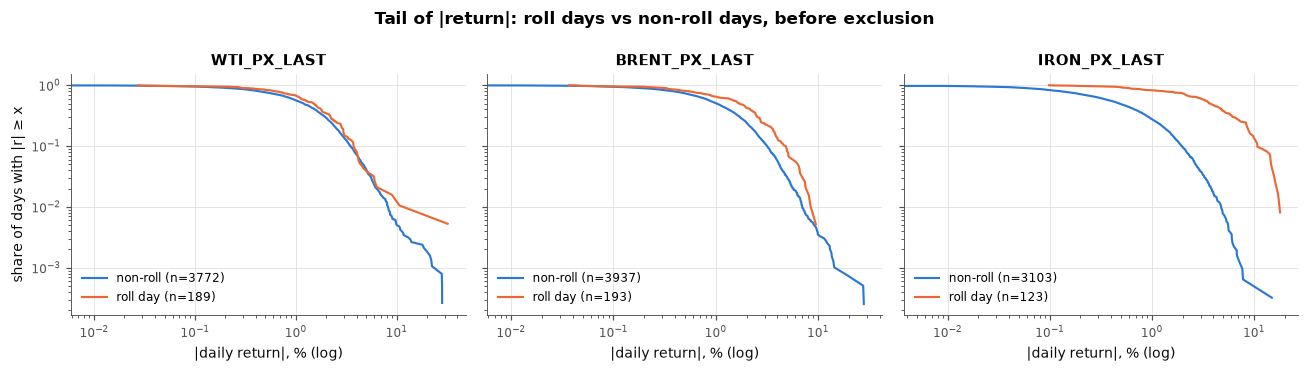

,n_roll,n_nonroll,mean_abs_roll_%,mean_abs_nonroll_%,std_roll_%,std_nonroll_%,share_gt_3sd_roll,share_gt_3sd_nonroll,perm_p_mean_abs
series,,,,,,,,,
WTI_PX_LAST,189,3772,1.9567,1.6653,3.3075,2.5092,0.0159,0.0138,0.0222
BRENT_PX_LAST,193,3937,2.1182,1.4662,2.8008,2.1786,0.0415,0.0145,0.0000
IRON_PX_LAST,123,3103,5.0081,0.8153,6.5477,1.2814,0.4797,0.0197,0.0000


Mean |return| (%) at own-row offsets around each roll day


,t-2,t-1,t+0,t+1,t+2
series,,,,,
BRENT_PX_LAST,1.4069,1.1356,2.1182,1.4252,1.7379
IRON_PX_LAST,0.1590,0.1430,5.0081,1.3710,1.2169
WTI_PX_LAST,1.6461,1.4811,1.9567,1.6352,1.4493


[PASS] WTI_PX_LAST: roll-day mean |r| exceeds non-roll (perm p < 0.05) - 1.96% vs 1.67%, p=0.0222
[PASS] WTI_PX_LAST: event-study peak at offset 0 (ticker aligned with price) - t-2=1.65, t-1=1.48, t+0=1.96, t+1=1.64, t+2=1.45
[PASS] BRENT_PX_LAST: roll-day mean |r| exceeds non-roll (perm p < 0.05) - 2.12% vs 1.47%, p=0.0000
[PASS] BRENT_PX_LAST: event-study peak at offset 0 (ticker aligned with price) - t-2=1.41, t-1=1.14, t+0=2.12, t+1=1.43, t+2=1.74
[PASS] IRON_PX_LAST: roll-day mean |r| exceeds non-roll (perm p < 0.05) - 5.01% vs 0.82%, p=0.0000
[PASS] IRON_PX_LAST: event-study peak at offset 0 (ticker aligned with price) - t-2=0.16, t-1=0.14, t+0=5.01, t+1=1.37, t+2=1.22


In [16]:
rng = np.random.default_rng(0)
cmp_rows, es_rows = [], []
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, c in zip(axes, FUT_TICKER):
    r, roll = RET[c], ROLL[c]
    ok = r.notna()
    a_roll, a_non = r[ok & roll].abs(), r[ok & ~roll].abs()
    sd_non = r[ok & ~roll].std()
    draws = np.array([rng.choice(a_non.values, len(a_roll), replace=False).mean() for _ in range(10_000)])
    cmp_rows.append({"series": c, "n_roll": len(a_roll), "n_nonroll": len(a_non),
                     "mean_abs_roll_%": 100 * a_roll.mean(), "mean_abs_nonroll_%": 100 * a_non.mean(),
                     "std_roll_%": 100 * r[ok & roll].std(), "std_nonroll_%": 100 * sd_non,
                     "share_gt_3sd_roll": (a_roll > 3 * sd_non).mean(), "share_gt_3sd_nonroll": (a_non > 3 * sd_non).mean(),
                     "perm_p_mean_abs": (draws >= a_roll.mean()).mean()})
    # event study on own-row positions around each roll
    pos = np.flatnonzero(roll.to_numpy())
    absr = r.abs().to_numpy()
    for k in range(-2, 3):
        p = pos + k
        p = p[(p >= 0) & (p < len(absr))]
        es_rows.append({"series": c, "offset": k, "mean_abs_%": 100 * np.nanmean(absr[p])})
    for vals, col, lab in [(a_non, BLUE, "non-roll"), (a_roll, ORANGE, "roll day")]:
        x = np.sort(100 * vals.values)
        ax.plot(x, 1 - np.arange(len(x)) / len(x), color=col, label=f"{lab} (n={len(x)})")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(c); ax.set_xlabel("|daily return|, % (log)")
    ax.legend(loc="lower left")
axes[0].set_ylabel("share of days with |r| ≥ x")
fig.suptitle("Tail of |return|: roll days vs non-roll days, before exclusion", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

rollcmp = pd.DataFrame(cmp_rows).set_index("series")
display(rollcmp)
es = pd.DataFrame(es_rows).pivot(index="series", columns="offset", values="mean_abs_%")
es.columns = [f"t{k:+d}" for k in es.columns]
print("Mean |return| (%) at own-row offsets around each roll day")
display(es)
for c in FUT_TICKER:
    check("4b", f"{c}: roll-day mean |r| exceeds non-roll (perm p < 0.05)", rollcmp.loc[c, "perm_p_mean_abs"] < 0.05,
          f"{rollcmp.loc[c, 'mean_abs_roll_%']:.2f}% vs {rollcmp.loc[c, 'mean_abs_nonroll_%']:.2f}%, "
          f"p={rollcmp.loc[c, 'perm_p_mean_abs']:.4f}")
    check("4b", f"{c}: event-study peak at offset 0 (ticker aligned with price)", es.loc[c].idxmax() == "t+0",
          ", ".join(f"{k}={v:.2f}" for k, v in es.loc[c].items()))

### 4b-ii. Volatility across the contract month (average-price settlement)

A generic that tracks a normal futures contract should be about equally volatile early and late in the
contract month. If the contract **settles on the monthly average** of a spot index, as SGX TSI iron ore does,
its price becomes more fixed as the month goes on. Daily volatility then falls toward zero before expiry and jumps
back on the roll. The generic's return then carries only a partial, time-varying exposure to spot.

The check compares mean |r| over the last 5 trading days before a roll with the first 5 after one, on non-roll
days only. A ratio well below 1 means average-price behaviour. This is **flagged, not fixed**. Any change, such as a
second-month generic, rescaling by remaining averaging days, or a different instrument, is a specification change
and belongs in `design_decisions.md` first.

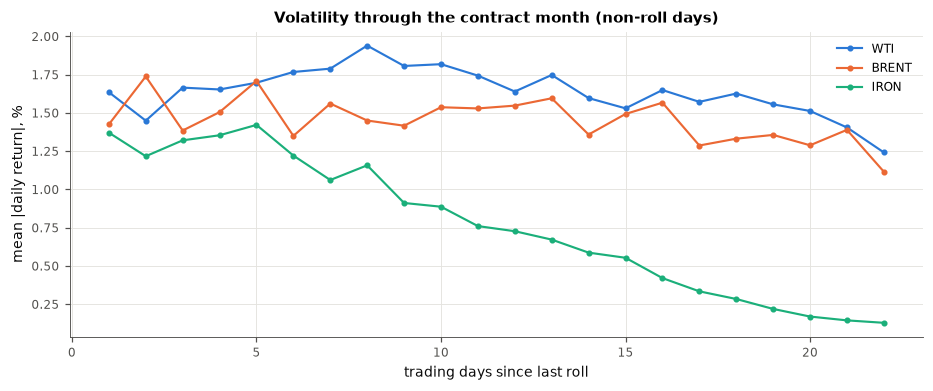

,mean_abs_first5_after_roll_%,mean_abs_last5_before_roll_%,late_over_early
series,,,
WTI_PX_LAST,1.6198,1.5601,0.9631
BRENT_PX_LAST,1.5522,1.3758,0.8863
IRON_PX_LAST,1.3369,0.2500,0.1870


[PASS] WTI_PX_LAST: no average-price decay through contract month (late/early > 0.5) - late 1.56% vs early 1.62%
[PASS] BRENT_PX_LAST: no average-price decay through contract month (late/early > 0.5) - late 1.38% vs early 1.55%
[FAIL] IRON_PX_LAST: no average-price decay through contract month (late/early > 0.5) - late 0.25% vs early 1.34%


In [17]:
fig, ax = plt.subplots(figsize=(10, 3.6))
cm = []
for c, col in zip(FUT_TICKER, [BLUE, ORANGE, "#1baf7a"]):
    r, roll = RET[c], ROLL[c]
    grp = roll.cumsum()
    since = grp.groupby(grp).cumcount()
    until = grp.groupby(grp).cumcount(ascending=False)
    d = pd.DataFrame({"a": 100 * r.abs(), "since": since, "until": until})[~roll & (grp > 0)]
    prof = d.groupby("since").a.mean().loc[1:22]
    ax.plot(prof.index, prof.values, color=col, marker="o", ms=3, label=c.replace("_PX_LAST", ""))
    early, late = d[d.since.between(1, 5)].a.mean(), d[d.until.between(0, 4)].a.mean()
    cm.append({"series": c, "mean_abs_first5_after_roll_%": early, "mean_abs_last5_before_roll_%": late,
               "late_over_early": late / early})
ax.set_xlabel("trading days since last roll"); ax.set_ylabel("mean |daily return|, %")
ax.set_title("Volatility through the contract month (non-roll days)")
ax.legend()
plt.show()
contract_month_vol = pd.DataFrame(cm).set_index("series")
display(contract_month_vol)
for c, r in contract_month_vol.iterrows():
    check("4b", f"{c}: no average-price decay through contract month (late/early > 0.5)", r.late_over_early > 0.5,
          f"late {r['mean_abs_last5_before_roll_%']:.2f}% vs early {r['mean_abs_first5_after_roll_%']:.2f}%")

### Pair panels (joined calendar)

This builds each pair's sample exactly as estimation should. Section 4c checks roll exclusion on it and section 5
reports its attrition. **Required series** are every price the regression needs on date *t*:

| Pair | FX | Commodity (+ ticker) | Controls | BCOM orthogonalized on |
|---|---|---|---|---|
| AUD | AUDUSD | iron ore (+ ticker) | DXY, BCOM | — (not a BCOM constituent) |
| CAD | USDCAD (inverted) | WTI (+ ticker) | DXY, BCOM | WTI |
| CLP | USDCLP (inverted) | LME copper | DXY, BCOM, HG1 | HG1 (COMEX) |
| NOK | USDNOK (inverted) | Brent (+ ticker) | DXY, BCOM | Brent |

Roll exclusion compares the ticker at *t* with the ticker at the **previous joined date**, not the previous own
row. If a roll falls on a date the join drops (a Chilean holiday, say), the switch is carried into the next joined
return, and that return has to go too. A check against own-calendar roll dates alone would miss it.

In [18]:
PAIRS = {
    "AUD": dict(fx="AUDUSD_PX_LAST", comm="IRON_PX_LAST", ticker="IRON_FUT_CUR_GEN_TICKER", ortho=None),
    "CAD": dict(fx="USDCAD_PX_LAST", comm="WTI_PX_LAST", ticker="WTI_FUT_CUR_GEN_TICKER", ortho="WTI_PX_LAST"),
    "CLP": dict(fx="USDCLP_PX_LAST", comm="COPPER_PX_LAST", ticker=None, ortho="HG1_PX_LAST"),
    "NOK": dict(fx="USDNOK_PX_LAST", comm="BRENT_PX_LAST", ticker="BRENT_FUT_CUR_GEN_TICKER", ortho="BRENT_PX_LAST"),
}
CONTROLS = ["DXY_PX_LAST", "BCOM_PX_LAST"]


def build_pair(pair):
    sp = PAIRS[pair]
    px_cols = list(dict.fromkeys([sp["fx"], sp["comm"], *CONTROLS] + ([sp["ortho"]] if sp["ortho"] else [])))
    req = px_cols + ([sp["ticker"]] if sp["ticker"] else [])
    union = pd.DatetimeIndex(sorted(set().union(*[OWN[c].index for c in req])), name="Date")
    st = pd.DataFrame({c: status_on(c, union) for c in req})
    val = pd.DataFrame({c: OWN[c].reindex(union) for c in req})
    joined = st.eq(OK).all(axis=1)
    J = val[joined]

    px = J[px_cols].astype(float)
    pos = px.gt(0)
    lret = np.log((px / px.shift()).where(pos & pos.shift(fill_value=False)))
    first = pd.Series(J.index == J.index[0], index=J.index)
    nonpos = ~first & lret.isna().any(axis=1)
    if sp["ticker"]:
        t = J[sp["ticker"]]
        roll = ~first & (t != t.shift())
    else:
        roll = pd.Series(False, index=J.index)

    ds = -lret[sp["fx"]] if INVERT[sp["fx"]] else lret[sp["fx"]]
    panel = pd.DataFrame({"ds": ds, "dc": lret[sp["comm"]], "ddxy": lret["DXY_PX_LAST"],
                          "dbcom": lret["BCOM_PX_LAST"]})
    if sp["ortho"]:
        panel["dortho"] = lret[sp["ortho"]]
    panel["ds_lead"] = ds.shift(-1)            # FX return to the next joined date
    if sp["ticker"]:
        panel["ticker"], panel["ticker_prev"] = J[sp["ticker"]], J[sp["ticker"]].shift()
    keep = ~first & ~nonpos & ~roll
    return dict(spec=sp, req=req, px_cols=px_cols, union=union, status=st, J=J, first=first,
                nonpos=nonpos, roll=roll, panel=panel, final=panel[keep],
                final_pred=panel[keep & panel["ds_lead"].notna()])


P = {p: build_pair(p) for p in PAIRS}
pd.DataFrame({p: {"union": len(b["union"]), "joined": len(b["J"]), "final_contemp": len(b["final"]),
                  "final_pred": len(b["final_pred"]), "first": b["final"].index.min().date(),
                  "last": b["final"].index.max().date()} for p, b in P.items()}).T

,union,joined,final_contemp,final_pred,first,last
AUD,4174,3059,2909,2908,2013-04-09,2025-09-19
CAD,4172,3897,3706,3705,2010-01-05,2025-09-19
CLP,4173,3599,3598,3597,2010-01-05,2025-09-23
NOK,4174,3898,3708,3707,2010-01-05,2025-09-23


### Calendar days spanned by each final-sample return

On the joined calendar a return runs from the previous joined date. A normal return spans 1 day, or 3 over a
weekend, and a holiday adds one or two more. A span beyond **5 calendar days** means the join has bridged a
data gap, and the "daily" return is really a multi-day return. The table counts these spans and the check lists
them. Whether to drop long-span returns is a specification decision for `design_decisions.md`.

In [19]:
spans, long_rows = {}, []
for p, b in P.items():
    J = b["J"].index
    gap = pd.Series(J.to_series().diff().dt.days.values, index=J).reindex(b["final"].index)
    spans[p] = gap.value_counts().sort_index()
    for d, g in gap[gap > 5].items():
        long_rows.append({"pair": p, "date": d.date(), "days_spanned": int(g)})
    check("5", f"{p}: no final-sample return spans more than 5 calendar days", (gap > 5).sum() == 0,
          f"{int((gap > 5).sum())} returns; longest {int(gap.max())} days ending {gap.idxmax().date()}")
display(pd.DataFrame(spans).fillna(0).astype(int).rename_axis("calendar_days_spanned").T)
long_spans = pd.DataFrame(long_rows)
long_spans.to_csv(OUT / "eda1_long_span_returns.csv", index=False)
with pd.option_context("display.max_rows", 60):
    display(long_spans.groupby("pair").days_spanned.describe() if len(long_spans) else "none")

[FAIL] AUD: no final-sample return spans more than 5 calendar days - 1 returns; longest 6 days ending 2016-01-27
[FAIL] CAD: no final-sample return spans more than 5 calendar days - 2 returns; longest 7 days ending 2010-02-12
[FAIL] CLP: no final-sample return spans more than 5 calendar days - 28 returns; longest 25 days ending 2012-03-05
[FAIL] NOK: no final-sample return spans more than 5 calendar days - 1 returns; longest 6 days ending 2016-01-27


calendar_days_spanned,1.0000,2.0000,3.0000,4.0000,5.0000,6.0000,7.0000,8.0000,9.0000,10.0000,11.0000,13.0000,15.0000,25.0000
AUD,2297,33,482,92,4,1,0,0,0,0,0,0,0,0
CAD,2874,43,646,136,5,1,1,0,0,0,0,0,0,0
CLP,2694,74,591,164,47,10,6,4,3,1,1,1,1,1
NOK,2903,45,626,128,5,1,0,0,0,0,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
pair,,,,,,,,
AUD,1.0000,6.0000,NaN,6.0000,6.0000,6.0000,6.0000,6.0000
CAD,2.0000,6.5000,0.7071,6.0000,6.2500,6.5000,6.7500,7.0000
CLP,28.0000,8.3929,3.9472,6.0000,6.0000,7.0000,9.0000,25.0000
NOK,1.0000,6.0000,NaN,6.0000,6.0000,6.0000,6.0000,6.0000


### 4c. Roll days are excluded downstream

Three assertions per futures pair, all on the final estimation sample:

1. no own-calendar roll date survives;
2. no surviving return spans two contracts (ticker at *t* equals ticker at the previous joined date);
3. the number of rolls *hidden by the join* is counted: own-calendar roll dates the join dropped, whose switch
   moved into a later joined return.

This is followed by the sign check from CLAUDE.md: every sign-adjusted FX return has to correlate **negatively**
with the dollar-index return.

In [20]:
hid = []
for p, b in P.items():
    sp, fin = b["spec"], b["final"]
    if sp["ticker"]:
        own_roll = ROLL[sp["comm"]]
        own_roll_dates = own_roll.index[own_roll]
        leaked = fin.index.intersection(own_roll_dates)
        spans = (fin["ticker"] != fin["ticker_prev"]).sum()
        hidden = own_roll_dates.difference(b["J"].index)
        check("4c", f"{p}: no own-calendar roll date in final sample", len(leaked) == 0, f"{len(leaked)} leaked")
        check("4c", f"{p}: no final-sample return spans two contracts", spans == 0, f"{spans} spanning")
        hid.append({"pair": p, "own_calendar_rolls": len(own_roll_dates),
                    "joined_calendar_rolls_excluded": int(b["roll"].sum()),
                    "rolls_on_dates_dropped_by_join": len(hidden),
                    "example_hidden": ", ".join(str(d.date()) for d in hidden[:5])})
    else:
        print(f"[info] {p}: {sp['comm']} is constant-maturity (no roll); "
              f"{sp['ortho']} rolls are undetectable - accepted, see CLAUDE.md")
display(pd.DataFrame(hid).set_index("pair"))

sign = {}
for p, b in P.items():
    rho = b["final"][["ds", "ddxy"]].corr().iloc[0, 1]
    sign[p] = rho
    check("4c", f"{p}: sign-adjusted FX return correlates negatively with dollar index", rho < 0, f"corr {rho:+.3f}")

[PASS] AUD: no own-calendar roll date in final sample - 0 leaked
[PASS] AUD: no final-sample return spans two contracts - 0 spanning
[PASS] CAD: no own-calendar roll date in final sample - 0 leaked
[PASS] CAD: no final-sample return spans two contracts - 0 spanning
[info] CLP: COPPER_PX_LAST is constant-maturity (no roll); HG1_PX_LAST rolls are undetectable - accepted, see CLAUDE.md
[PASS] NOK: no own-calendar roll date in final sample - 0 leaked
[PASS] NOK: no final-sample return spans two contracts - 0 spanning


,own_calendar_rolls,joined_calendar_rolls_excluded,rolls_on_dates_dropped_by_join,example_hidden
pair,,,,
AUD,152,149,14,"2013-09-02, 2014-03-03, 2014-09-01, 2016-05-02..."
CAD,189,188,3,"2014-02-21, 2018-03-21, 2025-09-23"
NOK,193,189,12,"2011-01-17, 2014-03-17, 2018-09-03, 2019-09-02..."


[PASS] AUD: sign-adjusted FX return correlates negatively with dollar index - corr -0.633
[PASS] CAD: sign-adjusted FX return correlates negatively with dollar index - corr -0.611
[PASS] CLP: sign-adjusted FX return correlates negatively with dollar index - corr -0.520
[PASS] NOK: sign-adjusted FX return correlates negatively with dollar index - corr -0.653


## 5. Coverage and attrition

**The cascade, per pair:** union of dates → inner join over the required series → drop the first joined date (no
previous price) → drop non-positive prices (log undefined) → drop rolls → **final N (contemporaneous)** → final
N with `Δs_{t+1}` available (predictive).

**Causes:** for each date the inner join drops, the loader status names which required series lacked a value,
and why. Per-year rates are over years where that series is covered. Each dropped date is also tagged with
a candidate holiday: fixed-date and rule-based holidays for the relevant markets (US, UK/LME, Canada, Chile,
Norway, Singapore/SGX, plus Chinese New Year), allowing Saturday→Friday and Sunday→Monday observance. The tags are
a best-effort explanation, not ground truth. `unlabelled` means no rule matched.

In [21]:
CNY = ["2010-02-14", "2011-02-03", "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
       "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12", "2022-02-01", "2023-01-22",
       "2024-02-10", "2025-01-29"]
CNY = {pd.Timestamp(d).year: pd.Timestamp(d) for d in CNY}

def easter(y):
    a, b, c = y % 19, y // 100, y % 100
    d, e = b // 4, b % 4
    f = (b + 8) // 25
    g = (b - f + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    return pd.Timestamp(y, (h + l - 7 * m + 114) // 31, (h + l - 7 * m + 114) % 31 + 1)

def nth_weekday(y, month, wd, n):
    # n-th (1-based) weekday wd (Mon=0) of month; n=-1 for last
    days = pd.date_range(pd.Timestamp(y, month, 1), periods=pd.Timestamp(y, month, 1).days_in_month)
    days = days[days.dayofweek == wd]
    return days[n - 1] if n > 0 else days[n]

FIXED = {  # (month, day): label
    (1, 1): "New Year", (12, 24): "Christmas Eve", (12, 25): "Christmas", (12, 26): "Boxing Day",
    (12, 31): "New Year's Eve", (7, 4): "US Independence Day", (6, 19): "US Juneteenth",
    (11, 11): "US Veterans / CA Remembrance Day", (7, 1): "Canada Day", (5, 1): "Labour Day",
    (5, 17): "Norway Constitution Day", (5, 21): "Chile Navy Day", (6, 29): "Chile Sts Peter & Paul",
    (7, 16): "Chile Virgen del Carmen", (8, 15): "Chile Assumption", (9, 18): "Chile Fiestas Patrias",
    (9, 19): "Chile Fiestas Patrias", (9, 17): "Chile Fiestas Patrias (bridge)", (9, 20): "Chile Fiestas Patrias (bridge)",
    (10, 12): "Chile Encuentro de Dos Mundos", (10, 31): "Chile Reformation Day", (11, 1): "Chile All Saints",
    (12, 8): "Chile Immaculate Conception", (6, 20): "Chile Indigenous Peoples", (6, 21): "Chile Indigenous Peoples",
    (8, 9): "Singapore National Day",
}

def holidays(y):
    out = {}
    for (m, d), lab in FIXED.items():
        h = pd.Timestamp(y, m, d)
        obs = h - pd.Timedelta(days=1) if h.dayofweek == 5 else h + pd.Timedelta(days=1) if h.dayofweek == 6 else h
        out.setdefault(h, []).append(lab)
        if obs != h:
            out.setdefault(obs, []).append(lab + " (observed)")
    e = easter(y)
    for off, lab in [(-3, "Maundy Thursday (NO)"), (-2, "Good Friday"), (1, "Easter Monday"),
                     (39, "Ascension (NO)"), (50, "Whit Monday (NO)")]:
        out.setdefault(e + pd.Timedelta(days=off), []).append(lab)
    for (m, wd, n), lab in {(1, 0, 3): "US MLK Day", (2, 0, 3): "US Presidents Day", (5, 0, -1): "US Memorial / UK Spring BH",
                            (9, 0, 1): "US Labor / CA Labour Day", (10, 0, 2): "US Columbus / CA Thanksgiving",
                            (11, 3, 4): "US Thanksgiving", (5, 0, 1): "UK Early May BH", (8, 0, -1): "UK Summer BH",
                            (8, 0, 1): "CA Civic Holiday"}.items():
        out.setdefault(nth_weekday(y, m, wd, n), []).append(lab)
    victoria = nth_weekday(y, 5, 0, -1) - pd.Timedelta(days=7) if nth_weekday(y, 5, 0, -1).day > 24 else nth_weekday(y, 5, 0, -1)
    out.setdefault(victoria, []).append("CA Victoria Day")
    if y in CNY:
        for k in range(0, 5):
            out.setdefault(CNY[y] + pd.Timedelta(days=k), []).append("Chinese New Year")
    return out

HOL = {}
for y in range(2009, 2027):
    for d, labs in holidays(y).items():
        HOL.setdefault(d, []).extend(labs)

def hol_label(d):
    return " / ".join(dict.fromkeys(HOL.get(d, ["unlabelled"])))

In [22]:
MARKET = {"AUDUSD_PX_LAST": "FX", "USDCAD_PX_LAST": "FX", "USDNOK_PX_LAST": "FX", "USDCLP_PX_LAST": "Chile (CLP onshore)",
          "WTI_PX_LAST": "NYMEX", "WTI_FUT_CUR_GEN_TICKER": "NYMEX", "BRENT_PX_LAST": "ICE", "BRENT_FUT_CUR_GEN_TICKER": "ICE",
          "IRON_PX_LAST": "SGX", "IRON_FUT_CUR_GEN_TICKER": "SGX", "COPPER_PX_LAST": "LME", "HG1_PX_LAST": "COMEX",
          "BCOM_PX_LAST": "BCOM (US)", "DXY_PX_LAST": "dollar index (US)"}

cascade, causes, combos = [], [], []
for p, b in P.items():
    st, J, union = b["status"], b["J"], b["union"]
    miss = st.ne(OK)
    dropped = miss[miss.any(axis=1)]
    n_first, n_nonpos, n_roll = int(b["first"].sum()), int(b["nonpos"].sum()), int(b["roll"].sum())
    yrs = lambda c: (min(OWN[c].index.max(), union.max()) - max(OWN[c].index.min(), union.min())).days / 365.25

    # per (series, status) cause table
    for c in b["req"]:
        for s in (SRC_NA, NO_ROW, UNCOVERED):
            hit = dropped.index[st.loc[dropped.index, c].eq(s)]
            if not len(hit):
                continue
            sole = hit[miss.loc[hit].sum(axis=1).eq(1)]
            labs = pd.Series([hol_label(d) for d in hit] if s != UNCOVERED else [], dtype=str).value_counts()
            causes.append({"pair": p, "series": c, "market": MARKET[c], "status": s, "n_dates": len(hit),
                           "n_sole_cause": len(sole),
                           "per_year": round(len(hit) / yrs(c), 1) if s != UNCOVERED else np.nan,
                           "span": f"{hit.min().date()} -> {hit.max().date()}",
                           "top_labels": "; ".join(f"{k} x{v}" for k, v in labs.head(6).items())})
    combo = dropped.apply(lambda r: " + ".join(r.index[r]), axis=1).value_counts()
    for k, v in combo.items():
        combos.append({"pair": p, "missing_series": k, "n_dates": v})

    pc = pd.DataFrame([x for x in causes if x["pair"] == p])
    main = pc.sort_values("n_dates", ascending=False).head(4)
    join_cause = "; ".join(f"{r.series} {r.status} {r.n_dates}" + (f" ({r.per_year}/yr)" if r.per_year == r.per_year else "")
                           for r in main.itertuples())
    nonpos_dates = ", ".join(str(d.date()) for d in b["nonpos"].index[b["nonpos"]])
    n_contemp, n_pred = len(b["final"]), len(b["final_pred"])
    stages = [
        ("0 union of dates", len(union), None, "any required series has a row"),
        ("1 inner join: all required series valid", len(J), len(union) - len(J), join_cause),
        ("2 first joined date (no previous price)", len(J) - n_first, n_first, str(J.index[0].date())),
        ("3 non-positive price (log return undefined)", len(J) - n_first - n_nonpos, n_nonpos,
         (nonpos_dates + " - treatment pending in design_decisions.md") if n_nonpos else ""),
        ("4 roll exclusion", n_contemp, n_roll,
         f"ticker changed vs previous joined date ({b['spec']['ticker']})" if b["spec"]["ticker"]
         else f"{b['spec']['comm']} has no roll; {b['spec']['ortho']} rolls undetectable (accepted)"),
        ("5 FINAL N contemporaneous", n_contemp, None,
         f"{b['final'].index.min().date()} -> {b['final'].index.max().date()}"),
        ("6 FINAL N predictive (ds_t+1 available)", n_pred, n_contemp - n_pred, "last joined date has no lead"),
    ]
    for stage, n, drop, note in stages:
        cascade.append({"pair": p, "stage": stage, "n_remaining": n, "n_dropped": drop, "cause": note})

attr = pd.DataFrame(cascade)
attr_causes = pd.DataFrame(causes)
attr_combos = pd.DataFrame(combos)
attr.to_csv(OUT / "sample_attrition.csv", index=False)
attr_causes.to_csv(OUT / "sample_attrition_causes.csv", index=False)
attr_combos.to_csv(OUT / "sample_attrition_combinations.csv", index=False)
print(f"wrote {OUT / 'sample_attrition.csv'} (+ _causes, _combinations)")
with pd.option_context("display.max_colwidth", 140):
    display(attr.set_index(["pair", "stage"]))

wrote outputs\diagnostics\sample_attrition.csv (+ _causes, _combinations)

n_remaining  n_dropped                                                                                                                                        cause
pair stage                                                                                                                                                                                                           
AUD  0 union of dates                                    4174        NaN                                                                                                                any required series has a row
     1 inner join: all required series valid             3059 1,115.0000        IRON_FUT_CUR_GEN_TICKER uncovered 851; IRON_PX_LAST uncovered 851; DXY_PX_LAST src_na 190 (12.0/yr); BCOM_PX_LAST no_row 143 (9.1/yr)
     2 first joined date (no previous price)             3058     1.0000                                                                                                                                   2013-04-08
     3 non-positive price (log return undefined)         3058     0.0000                                                                                                                                             
     4 roll exclusion                                    2909   149.0000                                                                             ticker changed vs previous joined date (IRON_FUT_CUR_GEN_TICKER)
     5 FINAL N contemporaneous                           2909        NaN                                                                                                                     2013-04-09 -> 2025-09-19
     6 FINAL N predictive (ds_t+1 available)             2908     1.0000                                                                                                                 last joined date has no lead
CAD  0 union of dates                                    4172        NaN                                                                                                                any required series has a row
     1 inner join: all required series valid             3897   275.0000  DXY_PX_LAST src_na 190 (12.0/yr); BCOM_PX_LAST no_row 143 (9.1/yr); WTI_FUT_CUR_GEN_TICKER no_row 141 (8.8/yr); WTI_PX_LAST no_row 141 (...
     2 first joined date (no previous price)             3896     1.0000                                                                                                                                   2010-01-04
     3 non-positive price (log return undefined)         3894     2.0000                                                                            2020-04-20, 2020-04-21 - treatment pending in design_decisions.md
     4 roll exclusion                                    3706   188.0000                                                                              ticker changed vs previous joined date (WTI_FUT_CUR_GEN_TICKER)
     5 FINAL N contemporaneous                           3706        NaN                                                                                                                     2010-01-05 -> 2025-09-19
     6 FINAL N predictive (ds_t+1 available)             3705     1.0000                                                                                                                 last joined date has no lead
CLP  0 union of dates                                    4173        NaN                                                                                                                any required series has a row
     1 inner join: all required series valid             3599   574.0000     USDCLP_PX_LAST no_row 274 (17.1/yr); DXY_PX_LAST src_na 190 (12.0/yr); BCOM_PX_LAST no_row 143 (9.1/yr); HG1_PX_LAST no_row 131 (8.3/yr)
     2 first joined date (no previous price)             3598     1.0000                                                                                                                              

### Which series caused each dropped date

Rows are ordered by number of dates. `n_sole_cause` counts the dates where this series was the only one missing.
Those are the dates this series alone costs the sample.

In [23]:
with pd.option_context("display.max_colwidth", 160):
    display(attr_causes.sort_values(["pair", "n_dates"], ascending=[True, False]).set_index(["pair", "series", "status"]))

market  n_dates  n_sole_cause  per_year                      span  \
pair series                   status                                                                                      
AUD  IRON_PX_LAST             uncovered                  SGX      851             0       NaN  2010-01-01 -> 2013-04-05   
     IRON_FUT_CUR_GEN_TICKER  uncovered                  SGX      851             0       NaN  2010-01-01 -> 2013-04-05   
     DXY_PX_LAST              src_na       dollar index (US)      190            46   12.0000  2010-01-01 -> 2025-11-11   
     BCOM_PX_LAST             no_row               BCOM (US)      143             8    9.1000  2010-01-18 -> 2025-09-01   
     AUDUSD_PX_LAST           uncovered                   FX       73             2       NaN  2025-09-22 -> 2025-12-31   
     BCOM_PX_LAST             uncovered            BCOM (US)       72             0       NaN  2010-01-01 -> 2025-12-31   
     IRON_PX_LAST             src_na                     SGX       43            31    3.4000  2013-04-30 -> 2020-12-25   
     DXY_PX_LAST              uncovered    dollar index (US)       33             0       NaN  2025-11-17 -> 2025-12-31   
     IRON_PX_LAST             no_row                     SGX       11             0    0.9000  2014-01-01 -> 2025-01-01   
     IRON_FUT_CUR_GEN_TICKER  no_row                     SGX       11             0    0.9000  2014-01-01 -> 2025-01-01   
CAD  DXY_PX_LAST              src_na       dollar index (US)      190            60   12.0000  2010-01-01 -> 2025-11-11   
     BCOM_PX_LAST             no_row               BCOM (US)      143             2    9.1000  2010-01-18 -> 2025-09-01   
     WTI_PX_LAST              no_row                   NYMEX      141             0    9.0000  2010-01-18 -> 2025-09-01   
     WTI_FUT_CUR_GEN_TICKER   no_row                   NYMEX      141             0    8.8000  2010-01-18 -> 2025-09-01   
     USDCAD_PX_LAST           uncovered                   FX       71             2       NaN  2025-09-22 -> 2025-12-31   
     BCOM_PX_LAST             uncovered            BCOM (US)       70             0       NaN  2010-01-01 -> 2025-12-31   
     WTI_PX_LAST              uncovered                NYMEX       67             0       NaN  2010-01-01 -> 2025-12-31   
     DXY_PX_LAST              uncovered    dollar index (US)       31             0       NaN  2025-11-17 -> 2025-12-31   
     WTI_FUT_CUR_GEN_TICKER   uncovered                NYMEX        1             0       NaN  2010-01-01 -> 2010-01-01   
CLP  USDCLP_PX_LAST           no_row     Chile (CLP onshore)      274           228   17.1000  2011-04-22 -> 2025-12-08   
     DXY_PX_LAST              src_na       dollar index (US)      190            49   12.0000  2010-01-01 -> 2025-11-11   
     BCOM_PX_LAST             no_row               BCOM (US)      143             0    9.1000  2010-01-18 -> 2025-09-01   
     HG1_PX_LAST              no_row                   COMEX      131             0    8.3000  2010-01-18 -> 2025-09-01   
     COPPER_PX_LAST           no_row                     LME      130            69    8.1000  2010-04-02 -> 2025-12-26   
     BCOM_PX_LAST             uncovered            BCOM (US)       71             6       NaN  2010-01-01 -> 2025-12-31   
     HG1_PX_LAST              uncovered                COMEX       65             0       NaN  2010-01-01 -> 2025-12-31   
     DXY_PX_LAST              uncovered    dollar index (US)       32             0       NaN  2025-11-17 -> 2025-12-31   
     HG1_PX_LAST              src_na                   COMEX       10             0    0.6000  2010-12-24 -> 2025-04-18   
     USDCLP_PX_LAST           uncovered  Chile (CLP onshore)        1             0       NaN  2010-01-01 -> 2010-01-01   
     COPPER_PX_LAST           uncovered                  LME        1             0       NaN  2010-01-01 -> 2010-01-01   
NOK  DXY_PX_LAST              src_na       dollar index (US)      190            60   12.0000  2010-01-01 -> 2025-11-1

In [24]:
print("Most common combinations of missing series on dropped dates (top 6 per pair)")
with pd.option_context("display.max_colwidth", 120):
    display(attr_combos.groupby("pair").head(6).set_index(["pair", "missing_series"]))

Most common combinations of missing series on dropped dates (top 6 per pair)


n_dates
pair missing_series                                                                
AUD  IRON_PX_LAST + IRON_FUT_CUR_GEN_TICKER                                     807
     DXY_PX_LAST + BCOM_PX_LAST                                                  83
     DXY_PX_LAST                                                                 46
     IRON_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST + IRON_FUT_CUR_GEN_TICKER         37
     AUDUSD_PX_LAST + BCOM_PX_LAST                                               36
     AUDUSD_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST                                 35
CAD  WTI_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST + WTI_FUT_CUR_GEN_TICKER          128
     DXY_PX_LAST                                                                 60
     USDCAD_PX_LAST + WTI_PX_LAST + BCOM_PX_LAST                                 33
     USDCAD_PX_LAST + WTI_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST                   33
     WTI_PX_LAST + BCOM_PX_LAST + WTI_FUT_CUR_GEN_TICKER                         14
     USDCAD_PX_LAST + BCOM_PX_LAST                                                3
CLP  USDCLP_PX_LAST                                                             228
     DXY_PX_LAST + BCOM_PX_LAST + HG1_PX_LAST                                   116
     COPPER_PX_LAST                                                              69
     DXY_PX_LAST                                                                 49
     BCOM_PX_LAST + HG1_PX_LAST                                                  29
     COPPER_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST + HG1_PX_LAST                   25
NOK  DXY_PX_LAST + BCOM_PX_LAST                                                 135
     DXY_PX_LAST                                                                 60
     BCOM_PX_LAST                                                                36
     BRENT_PX_LAST + DXY_PX_LAST + BCOM_PX_LAST + BRENT_FUT_CUR_GEN_TICKER       26
     BRENT_PX_LAST + BCOM_PX_LAST + BRENT_FUT_CUR_GEN_TICKER                     16
     BRENT_FUT_CUR_GEN_TICKER                                                     1

In [25]:
# one-line summary per pair, in-coverage holiday drops only (uncovered spans reported separately)
for p in PAIRS:
    pc = attr_causes[(attr_causes.pair == p)]
    inside = pc[pc.status != UNCOVERED].sort_values("n_dates", ascending=False)
    outside = pc[pc.status == UNCOVERED]
    parts = [f"{r.per_year}/yr {r.market} via {r.series.replace('_PX_LAST', '')} ({r.status})" for r in inside.itertuples()]
    print(f"{p}: " + ", ".join(parts))
    for r in outside.itertuples():
        print(f"     + {r.n_dates} dates outside {r.series} coverage: {r.span}")

AUD: 12.0/yr dollar index (US) via DXY (src_na), 9.1/yr BCOM (US) via BCOM (no_row), 3.4/yr SGX via IRON (src_na), 0.9/yr SGX via IRON (no_row), 0.9/yr SGX via IRON_FUT_CUR_GEN_TICKER (no_row)
     + 73 dates outside AUDUSD_PX_LAST coverage: 2025-09-22 -> 2025-12-31
     + 851 dates outside IRON_PX_LAST coverage: 2010-01-01 -> 2013-04-05
     + 33 dates outside DXY_PX_LAST coverage: 2025-11-17 -> 2025-12-31
     + 72 dates outside BCOM_PX_LAST coverage: 2010-01-01 -> 2025-12-31
     + 851 dates outside IRON_FUT_CUR_GEN_TICKER coverage: 2010-01-01 -> 2013-04-05
CAD: 12.0/yr dollar index (US) via DXY (src_na), 9.1/yr BCOM (US) via BCOM (no_row), 9.0/yr NYMEX via WTI (no_row), 8.8/yr NYMEX via WTI_FUT_CUR_GEN_TICKER (no_row)
     + 71 dates outside USDCAD_PX_LAST coverage: 2025-09-22 -> 2025-12-31
     + 67 dates outside WTI_PX_LAST coverage: 2010-01-01 -> 2025-12-31
     + 31 dates outside DXY_PX_LAST coverage: 2025-11-17 -> 2025-12-31
     + 70 dates outside BCOM_PX_LAST coverage: 2010-

### Coverage end dates

The common sample ends at the **earliest last date** among a pair's required series. A short series at the end of
the sample shows up in the table above as `uncovered`. This table lists each pair's binding series directly.

In [26]:
end = pd.DataFrame([{"pair": p, **{c.replace("_PX_LAST", ""): OWN[c].index.max().date() for c in b["px_cols"]},
                     "binding_series": min(b["px_cols"], key=lambda c: OWN[c].index.max()),
                     "sample_end": min(OWN[c].index.max() for c in b["px_cols"]).date()} for p, b in P.items()]).set_index("pair")
end

,AUDUSD,IRON,DXY,BCOM,binding_series,sample_end,USDCAD,WTI,USDCLP,COPPER,HG1,USDNOK,BRENT
pair,,,,,,,,,,,,,
AUD,2025-09-19,2025-12-31,2025-11-14,2025-09-23,AUDUSD_PX_LAST,2025-09-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CAD,NaN,NaN,2025-11-14,2025-09-23,USDCAD_PX_LAST,2025-09-19,2025-09-19,2025-09-26,NaN,NaN,NaN,NaN,NaN
CLP,NaN,NaN,2025-11-14,2025-09-23,BCOM_PX_LAST,2025-09-23,NaN,NaN,2025-12-31,2025-12-31,2025-10-01,NaN,NaN
NOK,NaN,NaN,2025-11-14,2025-09-23,BCOM_PX_LAST,2025-09-23,NaN,NaN,NaN,NaN,NaN,2025-12-31,2025-12-31


## Checks summary

Every check run above. **FAIL rows stay in the output.** Each one needs a decision recorded in
`design_decisions.md`, or a fix in the data or loader. Do not drop them.

In [27]:
checks = pd.DataFrame(CHECKS)
checks.to_csv(OUT / "eda1_checks.csv", index=False)
print(checks.result.value_counts().to_string())
with pd.option_context("display.max_colwidth", 200):
    display(checks[checks.result == "FAIL"])

result
PASS    104
FAIL     13


,section,check,result,detail
31,1,"USDCLP_PX_LAST: rows within 150 of ~4,100",FAIL,"3898 rows, 2010-01-04 -> 2025-12-31"
34,1,"IRON_PX_LAST: rows within 150 of ~4,100",FAIL,"3312 rows, 2013-04-08 -> 2025-12-31"
60,2,WTI_PX_LAST (ex-roll): daily std in expected commodity band 1.5-2.5%,FAIL,2.51%
64,2,IRON_PX_LAST (ex-roll): daily std in expected commodity band 1.5-2.5%,FAIL,1.28%
66,2,COPPER_PX_LAST: daily std in expected commodity band 1.5-2.5%,FAIL,1.33%
68,2,HG1_PX_LAST: daily std in expected commodity band 1.5-2.5%,FAIL,1.50%
73,2,USDNOK_PX_LAST: FX skew near zero (|skew| < 0.5),FAIL,skew -0.50
86,3c,every non-roll >5sigma move matched to a known event,FAIL,COPPER_PX_LAST 2011-10-20; IRON_PX_LAST 2016-11-11; IRON_PX_LAST 2017-05-04; IRON_PX_LAST 2021-05-10; IRON_PX_LAST 2021-09-06; IRON_PX_LAST 2021-10-11; USDCLP_PX_LAST 2011-11-30
102,4b,IRON_PX_LAST: no average-price decay through contract month (late/early > 0.5),FAIL,late 0.25% vs early 1.34%
103,5,AUD: no final-sample return spans more than 5 calendar days,FAIL,1 returns; longest 6 days ending 2016-01-27


## Findings from the first run (2026-09-27)

These come from reading the output above, so re-check them if the data changes. None of them has been fixed in
the data. Each needs a decision recorded in `design_decisions.md`, or a re-pull.

1. **`USD_Index_DXY_Daily.csv` is not ICE DXY.** It reads 92.36 on 2010-01-04 and 128.4 at the 2022-09 peak,
   where DXY was about 77.5 and 114. Its gaps fall on US federal holidays, including Columbus Day, Veterans Day and
   the Fed's Feb-2010 snow closure. That matches the **Fed H.10 nominal broad dollar index** (Jan-2006 = 100).
   The sign check still passes, but the control is a different index from the one the spec names, and CAD's weight
   in it is not 9.1%. It also costs about 12 dates a year (190 `src_na`) that ICE DXY would have.
2. **USDCLP coverage is patchy from Nov-2011 to Oct-2012.** There are 121 missing weekdays in 2012 and 31 in 2011,
   including 22 in a row from 11-Nov to 16-Dec 2011. On the joined calendar, 28 CLP "daily" returns span 6–25
   calendar days. The 2011-11-30 USDCLP ">5σ move" is really a 20-day return. This needs a re-pull (another
   pricing source) or a recorded rule for long-span returns.
3. **SGX iron ore behaves as an average-price contract.** Mean |r| falls from about 1.3% just after a roll to
   about 0.2% before the next, while crude is flat. The source log says "not monthly-average settled". The data
   says the opposite. On late-month days the AUD regressor carries only a fraction of the spot move, which attenuates β for the
   clean pair. Options such as a second-month generic, or scaling by remaining averaging days, are spec changes
   and must be recorded before estimation.
4. **Common sample ends 2025-09-19 (AUD, CAD) and 2025-09-23 (CLP, NOK).** The binding series are the AT-04 FX
   CSV and the BCOM CSV, not the 2025-12-31 Bloomberg pulls.
5. **WTI −$37.63** makes the CAD returns on 2020-04-20 and 04-21 undefined. They sit in their own attrition stage
   until a treatment is recorded.
6. **Loader date parsing:** the CSV readers infer the date format. Every raw date string is ISO and the strict
   parse matches, so no dates are wrong today. `data_compile.py` should still pass `format="%Y-%m-%d"`.
7. **Band misses** (WTI 2.51%, LME copper 1.33%, HG1 1.50%, iron ore 1.28%, NOK skew −0.50) are small or explained:
   copper vol is genuinely about 1.3–1.5%, and iron's is low because of item 3. They are kept as recorded FAILs.
8. **Unexplained >5σ moves** still to verify on the terminal: LME copper 2011-10-20, and iron ore 2016-11-11,
   2017-05-04, 2021-05-10, 2021-09-06 and 2021-10-11. Several of the iron dates follow Chinese holidays.